## Phage Exploratory Data Analysis

### Segment into Kmers & Heatmap
Done using manipulations.py > fasta_to_kmerdf

In [ ]:
import pandas as pd
from Bio import SeqIO
import numpy as np
import os, sys
from tqdm import tqdm

raw_data_path = "../raw_data/"
data_prod_path = "../data_prod/"
scripts_path = "../scripts/"

sys.path.append(scripts_path)
print(sys.path)

from manipulations import fasta_to_kmerdf


In [ ]:
K = 8
phage_kmer_df = fasta_to_kmerdf(raw_data_path+"phagehost_KU/phage_cleaned.fasta", k=K)
display(phage_kmer_df.head())
phage_kmer_counts_df = fasta_to_kmerdf(raw_data_path+"phagehost_KU/phage_cleaned.fasta", k=K, relative=False)


In [ ]:
records = list(SeqIO.parse(raw_data_path + "data2_phages.fasta", "fasta"))
print(len(records))

In [ ]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from plotly.subplots import make_subplots

# Interactive heatmap with plotly, with barplot of row sums on the right

import plotly.graph_objects as go

# Create heatmap
heatmap = go.Heatmap(
    z=phage_kmer_df.values*100,  # Scale to percentage
    x=phage_kmer_df.columns,
    y=phage_kmer_df.index,
    colorscale="Turbo",
    colorbar=dict(title=f"Relative {K}mer Frequency (%)"),
    showscale=True
)

# Create barplot for row sums
barplot = go.Bar(
    x=phage_kmer_counts_df.sum(axis=1).values,
    y=phage_kmer_counts_df.index,
    orientation='h',
    marker=dict(color='gray'),
    showlegend=False,
    xaxis='x2',
    yaxis='y2'
)

# Create subplots
fig = make_subplots(
    rows=1, cols=2,
    column_widths=[0.85, 0.15],
    shared_yaxes=True,
    horizontal_spacing=0.00,
    subplot_titles=[f"{K}mer Frequency Heatmap for Phage Sequences", f"{K}mer Counts"]
)

fig.add_trace(heatmap, row=1, col=1)
fig.add_trace(barplot, row=1, col=2)

fig.update_xaxes(title_text=f"{K}mers (Total: {phage_kmer_df.shape[1]})", showticklabels=False, row=1, col=1)
fig.update_xaxes(title_text="Counts", row=1, col=2)
fig.update_yaxes(title_text=f"Phage Sequences (Total: {phage_kmer_df.shape[0]})", row=1, col=1)

fig.update_layout(
    width=1200,
    height=600,
    title_text=f"Distribution of {K}mers Across Phage Sequences, with {K}mer Counts",
    showlegend=False
)

fig.show()

In [ ]:
#Static heatmap with seaborn
plt.figure(figsize=(12,8))
sns.heatmap(phage_kmer_df, cmap="rocket_r")
plt.xlabel(f"{K}mers (Total: {phage_kmer_df.shape[1]})")
plt.ylabel(f"Phage Sequences (Total: {phage_kmer_df.shape[0]})")
plt.title("Kmer Frequency Heatmap for Phage Sequences")

### PCA of high contributing kmers

In [ ]:
import numpy as np
import pandas as pd
from analysis import perform_pca, pca_biplot

phage_labels = [name.split("_")[-1] for name in phage_kmer_df.index.tolist()] # Phage names only
bacteria_hosts = [name.split("_")[0] for name in phage_kmer_df.index.tolist()] # Host bacteria and phage names
features = phage_kmer_df.columns.tolist()  # Kmer features

#### Define PCA first then call biplot - controls pca externally (eg. number of components)
#pca, components, coeff = perform_pca(phage_kmer_df, n_components=2)
#pca_biplot(components, pca.components_.T, PCA = pca, labels = features, n_features_to_plot=10, hide_labels=[True, False])

#### Directly call pca_biplot which performs PCA internally
pca_biplot(data = phage_kmer_df,
            vec_labels = features, point_labels = phage_labels, n_features_to_plot=10, hide_labels=[True, False], color_on=bacteria_hosts)

pca_biplot(data = phage_kmer_df,
           vec_labels = features, point_labels = phage_labels, n_features_to_plot=10, hide_labels=[False, True])


It seems that the phages can be divided into 3 main groupings

In [ ]:
phage_kmer_df.index.tolist()

In [ ]:
phage_pca_clusters = {
    "C1" : ["Pectobacterium_phage_Koroua", "Pectobacterium_phage_Ymer", "Pectobacterium_phage_Amona", "Pectobacterium_phage_Poppous", "Pectobacterium_phage_Taid"],
    "C2" : ["Pectobacterium_phage_Vims", "Lelliottia_phage_Zann", "Pectobacterium_phage_Sabo", "Pectobacterium_phage_Abuela", "Pectobacterium_phage_Guf", "Pectobacterium_phage_Magnum"]

}

### Clustering strains

In [ ]:
n = 500
k = 12
input_phage_path = f"SM_sketches/PhageMinhash_n{n}_k{k}_rev/" 
input_bact_path = f"SM_sketches/BactMinhash_n{n}_k{k}_rev/" 

import sourmash
from Bio import SeqIO
from tqdm import tqdm

records = list(SeqIO.parse(raw_data_path+"phagehost_KU/phage_cleaned.fasta", "fasta"))

#Constructing minhashes for all records
minhashes = []
for rec in tqdm(records, desc="Constructing minhashes for all records", unit="seq"):
    #print("Record:", rec.id, len(rec.seq))
    mh = sourmash.MinHash(n=n, ksize=k) #each record gets its own minhash
    for i in range(0, len(rec.seq) - k + 1):
        kmer = str(rec.seq[i:i+k])
        mh.add_sequence(kmer, force=True)
    minhashes.append(mh)

#Comparing all minhashes
similarity_matrix = dict()
for i, e in enumerate(minhashes):
    sim_inner = dict()
    for j, e2 in enumerate(minhashes):
        x = e.jaccard(minhashes[j])
        sim_inner[records[j].id.split("_")[-1]] = x
    similarity_matrix[records[i].id.split("_")[-1]] = sim_inner

In [ ]:
import seaborn as sns
sns.clustermap(pd.DataFrame(similarity_matrix).T, cmap="viridis", figsize=(10, 10))

In [ ]:
sim_df = pd.DataFrame(similarity_matrix)
sim_df.head()

In [ ]:
from sklearn.cluster import AgglomerativeClustering
cluster_sim = 0.95

# We convert similarity to 'distance' (Distance = 1 - Similarity)
df_dist = 1 - sim_df

# 2. Initialize the clusterer
# 'distance_threshold' is your similarity cutoff
# 'n_clusters=None' is required when using a distance threshold
model = AgglomerativeClustering(
    metric='precomputed', 
    linkage='average', 
    distance_threshold=1 - cluster_sim,
    n_clusters=None
)

# 3. Fit and get labels
cluster_labels = model.fit_predict(df_dist)

# 4. Add labels back to your index
results = pd.Series(cluster_labels, index=sim_df.index, name='Cluster')
print(results.sort_values())

## Phage Statistics

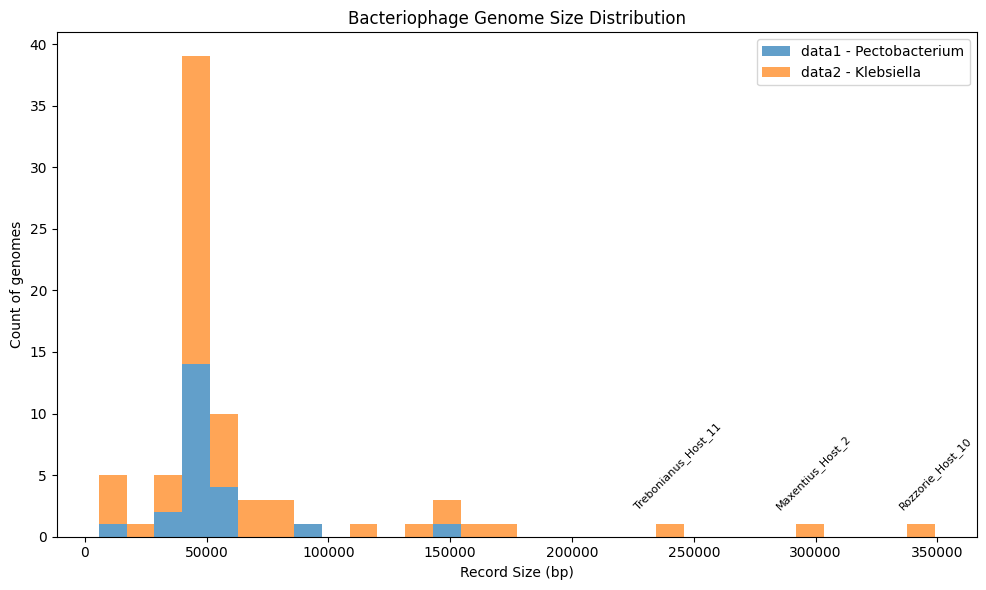

In [4]:
from Bio import SeqIO
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from paths import raw_data_path

records_dataset1 = list(SeqIO.parse(raw_data_path+"phagehost_KU/phage_cleaned.fasta", "fasta"))
records_dataset2 = list(SeqIO.parse(raw_data_path+"phagehost_KU/data2_phages.fasta", "fasta"))
records = [records_dataset1, records_dataset2]

def plot_record_size_distribution(records, title="Distribution of Record Sizes"):
    fig, ax = plt.subplots(figsize=(10, 6))
    
    if len(records) == 2:
        labels = ["data1 - Pectobacterium", "data2 - Klebsiella"]
        record_sizes_list = []
        for i, record_set in enumerate(records):
            record_sizes = [len(rec.seq) for rec in record_set]
            record_sizes_list.append(record_sizes)
        
        ax.hist(record_sizes_list, bins=30, label=labels, stacked=True, alpha=0.7)

    elif len(records) == 1:
        record_sizes = [len(rec.seq) for rec in records[0]]
        sns.histplot(record_sizes, bins=30, kde=True, label="Dataset", ax=ax, alpha=0.6)
    else:
        raise ValueError("Expected 1 or 2 sets of records, got {}".format(len(records)))

    # Annotate large records across all datasets
    for record_set in records:
        for rec in record_set:
            seq_len = len(rec.seq)
            if seq_len > 200_000:
                ax.annotate(
                    rec.id,
                    xy=(seq_len, 0),
                    xytext=(seq_len, ax.get_ylim()[1] * 0.05),  # slight offset from x-axis
                    rotation=45,
                    fontsize=8,
                    ha="center",
                    va="bottom"
                )

    ax.set_title(title)
    ax.set_xlabel("Record Size (bp)")
    ax.set_ylabel("Count of genomes")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../fig/phage_genome_size_distribution.png", dpi=300)
    plt.show()
plot_record_size_distribution(records, "Bacteriophage Genome Size Distribution")

Annotating Rozzorie_Host_10 with GC content 31.55% (Bin 0, annotated 0 times before)


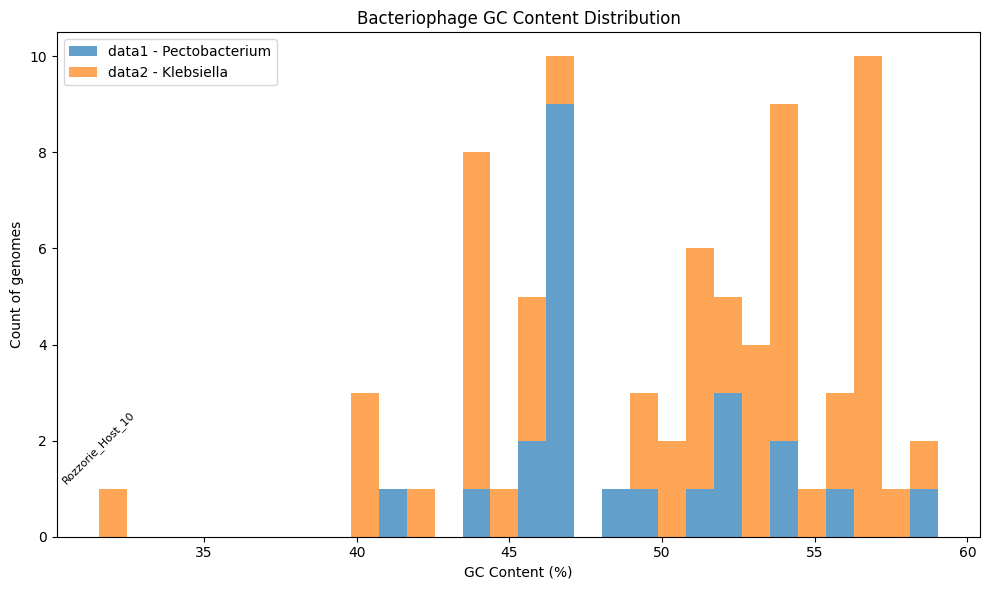

In [11]:
from Bio.SeqUtils import gc_fraction

def plot_gc_distribution(records, title="Distribution of GC Content"):
    fig, ax = plt.subplots(figsize=(10, 6))

    if len(records) == 2:
        labels = ["data1 - Pectobacterium", "data2 - Klebsiella"]
        gc_contents_list = []
        for record_set in records:
            gc_contents = [gc_fraction(rec.seq) * 100 for rec in record_set]
            gc_contents_list.append(gc_contents)

        ax.hist(gc_contents_list, bins=30, label=labels, stacked=True, alpha=0.7)

    elif len(records) == 1:
        gc_contents = [gc_fraction(rec.seq) * 100 for rec in records[0]]
        gc_contents_list = [gc_contents]
        sns.histplot(gc_contents, bins=30, kde=True, label="Dataset", ax=ax, alpha=0.6)

    else:
        raise ValueError("Expected 1 or 2 sets of records, got {}".format(len(records)))

    # Annotate GC outliers (<40% or >60%) using binning to avoid label overlap
    gc_contents_long = [gc for sublist in gc_contents_list for gc in sublist]
    bin_counts, bin_edges = np.histogram(gc_contents_long, bins=30)
    bin_annotation_counts = {}
    for record_set in records:
        for rec in record_set:
            gc_value = gc_fraction(rec.seq) * 100
            bin_idx = np.digitize(gc_value, bin_edges, right=False) - 1
            bin_idx = max(0, min(bin_idx, len(bin_edges) - 2))
            bar_height = bin_counts[bin_idx]
            label_step = max(0.05, bar_height * 0.05)
            annotated_count = bin_annotation_counts.get(bin_idx, 0)
            if gc_value < 35 or gc_value > 60:
                print(f"Annotating {rec.id} with GC content {gc_value:.2f}% (Bin {bin_idx}, annotated {annotated_count} times before)")
                ax.annotate(
                    rec.id,
                    xy=(gc_value, bar_height),
                    xytext=(gc_value, bar_height + label_step * (annotated_count + 1)),
                    textcoords="data",
                    rotation=45,
                    fontsize=8,
                    ha="center",
                    va="bottom",
                )
                bin_annotation_counts[bin_idx] = annotated_count + 1

    ax.set_title(title)
    ax.set_xlabel("GC Content (%)")
    ax.set_ylabel("Count of genomes")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../fig/phage_gc_distribution.png", dpi=300)
    plt.show()

plot_gc_distribution(records, "Bacteriophage GC Content Distribution")

## Phage Annotation Summary

In [17]:
from paths import data_prod_path
import pandas as pd

phold_stats_dir = os.path.join(data_prod_path, "phold_statistics")
phold_d1 = pd.read_csv(os.path.join(phold_stats_dir, "phold_summary_dataset1.csv"))
phold_d2 = pd.read_csv(os.path.join(phold_stats_dir, "phold_summary_dataset2.csv"))

display(phold_d1.head())
display(phold_d2.head())


print("Average coverage of phage sequences by phold:")
print("Dataset 1 (Pectobacterium): {:.2f}%".format(phold_d1["pct_genome_known"].mean()))
print("Dataset 2 (Klebsiella): {:.2f}%".format(phold_d2["pct_genome_known"].mean()))

,phage,genome_length_bp,total_cds,known_function_cds,unknown_function_cds,pct_known_cds,pct_unknown_cds,known_function_bp,unknown_function_bp,noncoding_bp,pct_genome_known,pct_genome_unknown,pct_genome_noncoding,method_foldseek,method_pharokka,method_none
0,Lelliottia_phage_Pantea,150009,298,119,179,39.9,60.1,92478,48444,9087,61.6,32.3,6.1,210,49,39
1,Lelliottia_phage_Rap,40557,64,30,34,46.9,53.1,27678,10908,1971,68.2,26.9,4.9,42,4,18
2,Lelliottia_phage_Zann,51744,97,41,56,42.3,57.7,34722,13467,3555,67.1,26.0,6.9,49,18,30
3,Morganella_phage_Rip,59319,86,44,42,51.2,48.8,41403,16338,1578,69.8,27.5,2.7,55,11,20
4,Morganella_phage_Rup,60952,84,45,39,53.6,46.4,43242,15993,1717,70.9,26.2,2.8,56,11,17


,phage,genome_length_bp,total_cds,known_function_cds,unknown_function_cds,pct_known_cds,pct_unknown_cds,known_function_bp,unknown_function_bp,noncoding_bp,pct_genome_known,pct_genome_unknown,pct_genome_noncoding,method_foldseek,method_pharokka,method_none
0,Anivius_Host_6,59222,100,47,53,47.0,53.0,40392,15282,3548,68.2,25.8,6.0,53,7,40
1,Anthemius_Host_3,48526,64,39,25,60.9,39.1,39279,7674,1573,80.9,15.8,3.2,51,2,11
2,Arcadius_Host_2,58055,90,43,47,47.8,52.2,41409,14637,2009,71.3,25.2,3.5,66,7,17
3,Arruntis_Host_7,44193,62,28,34,45.2,54.8,33894,8796,1503,76.7,19.9,3.4,42,10,10
4,Artabasdos_Host_5,148632,317,96,221,30.3,69.7,79614,58080,10938,53.6,39.1,7.4,160,53,104


Average coverage of phage sequences by phold:
Dataset 1 (Pectobacterium): 73.44%
Dataset 2 (Klebsiella): 72.61%


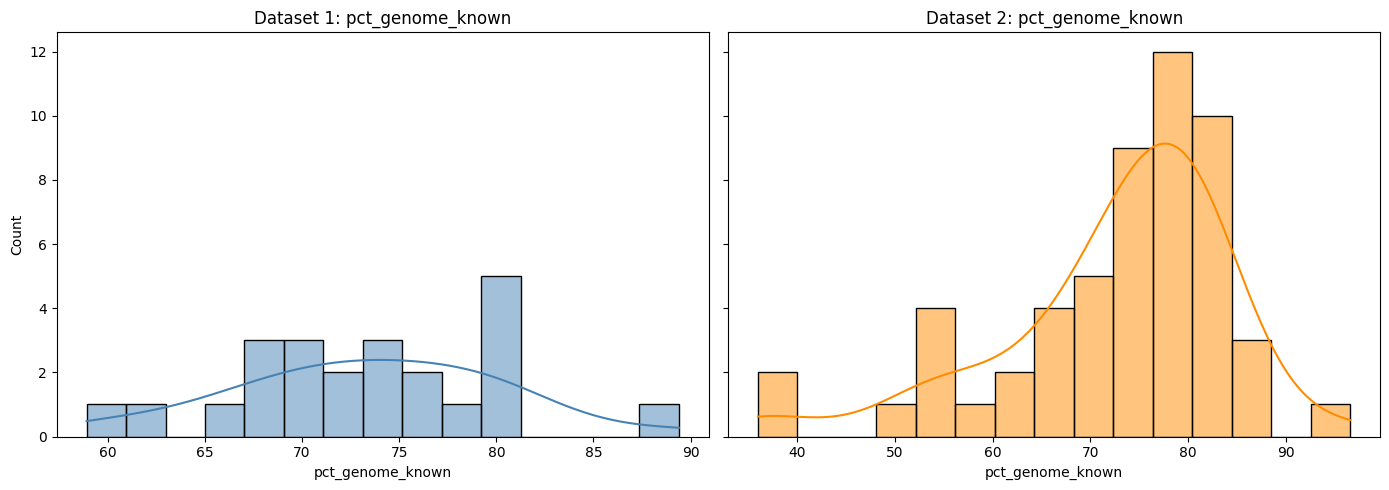

Dataset 1 outlier bounds: [54.23, 93.62]


,phage,pct_genome_known


Dataset 2 outlier bounds: [50.26, 98.96]


,phage,pct_genome_known
22,Geta_Host_4,36.0
11,Caracalla_Host_4,37.3
30,Leonitus_Host_4,48.2


In [22]:
# Distribution of pct_genome_known and outlier detection via IQR

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

sns.histplot(phold_d1["pct_genome_known"], bins=15, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Dataset 1: pct_genome_known")
axes[0].set_xlabel("pct_genome_known")
axes[0].set_ylabel("Count")

sns.histplot(phold_d2["pct_genome_known"], bins=15, kde=True, color="darkorange", ax=axes[1])
axes[1].set_title("Dataset 2: pct_genome_known")
axes[1].set_xlabel("pct_genome_known")

plt.tight_layout()
plt.savefig("../fig/phold_coverage_distribution.png", dpi=300)
plt.show()

def iqr_outliers(df, col="pct_genome_known"):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)].copy()
    return outliers, lower, upper

outliers_d1, lower_d1, upper_d1 = iqr_outliers(phold_d1)
outliers_d2, lower_d2, upper_d2 = iqr_outliers(phold_d2)

print(f"Dataset 1 outlier bounds: [{lower_d1:.2f}, {upper_d1:.2f}]")
display(outliers_d1[["phage", "pct_genome_known"]].sort_values("pct_genome_known"))

print(f"Dataset 2 outlier bounds: [{lower_d2:.2f}, {upper_d2:.2f}]")
display(outliers_d2[["phage", "pct_genome_known"]].sort_values("pct_genome_known"))

